In [2]:
# Imports:
import re
import numpy as np
import math
import matplotlib.pyplot as plt
import networkx as nx

### Parse results from file

In [3]:
# Load result file

# 5 Samples: result_V5ODGq.txt
# 3 Poses, 10 Times (love, point, victory): result_riclTY.txt
# 3 Poses, 10 Times (fist, thumbs up, thumbs down): result_RD9SsZ.txt
# 7 Poses, 5 Times: result_dSAjfd.txt
input_file = "./results/result_dSAjfd.txt"

results = open(input_file, "r")

In [4]:
# Define the custom object types

class Category:
    def __init__(self, index, score, display_name, category_name):
        self.index = index
        self.score = score
        self.display_name = display_name
        self.category_name = category_name

class NormalizedLandmark:
    def __init__(self, x, y, z, visibility, presence):
        self.x = x
        self.y = y
        self.z = z
        self.visibility = visibility
        self.presence = presence

class Landmark:
    def __init__(self, x, y, z, visibility, presence):
        self.x = x
        self.y = y
        self.z = z
        self.visibility = visibility
        self.presence = presence

In [5]:
# Function to parse all Hand Landmark Result data from one line in the file

def parse(data_string):
    # Extract handedness data using regex
    handedness_match = re.search(r'handedness=\[\[.*?\]\]', data_string)
    if handedness_match:
        handedness_data = handedness_match.group()
        #print(handedness_data)

        # Extract hand_landmarks data using regex
        hand_landmarks_match = re.search(r'hand_landmarks=\[\[.*?\]\]', data_string)
        hand_landmarks_data = hand_landmarks_match.group()
        #print(hand_landmarks_data)

        # Extract hand_world_landmarks data using regex
        hand_world_landmarks_match = re.search(r'hand_world_landmarks=\[\[.*?\]\]', data_string)
        hand_world_landmarks_data = hand_world_landmarks_match.group()

        # Parse handedness data
        category_entries = re.findall(r'Category\(.*?\)', handedness_data)
        handedness = []
        for entry in category_entries:
                category_match = re.search(r"index=(.*?), score=(.*?), display_name='(.*?)', category_name='(.*?)", entry)
                index = int(category_match.group(1))
                score = float(category_match.group(2))
                display_name = category_match.group(3)
                category_name = category_match.group(4)
                category = Category(index, score, display_name, category_name)
                handedness.append(category)

        # Parse hand_landmarks data
        landmark_entries = re.findall(r'NormalizedLandmark\(.*?\)', hand_landmarks_data)
        normalized_landmarks = []
        hand_landmarks = []
        for idx, entry in enumerate(landmark_entries):
            if len(hand_landmarks) == 21:
                normalized_landmarks.append(hand_landmarks)
                hand_landmarks = []

            match = re.search(r'x=(.*?), y=(.*?), z=(.*?), visibility=(.*?), presence=(.*?)\)', entry)
            x = float(match.group(1))
            y = float(match.group(2))
            z = float(match.group(3))
            visibility = float(match.group(4))
            presence = float(match.group(5))
            normalized_landmark = NormalizedLandmark(x, y, z, visibility, presence)
            hand_landmarks.append(normalized_landmark)

        normalized_landmarks.append(hand_landmarks)
        hand_landmarks = []

        # Parse hand_world_landmarks data
        landmark_entries = re.findall(r'Landmark\(.*?\)', hand_world_landmarks_data)
        world_landmarks = []
        for entry in landmark_entries:
            if len(hand_landmarks) == 21:
                world_landmarks.append(hand_landmarks)
                hand_landmarks = []

            match = re.search(r'x=(.*?), y=(.*?), z=(.*?), visibility=(.*?), presence=(.*?)\)', entry)
            x = float(match.group(1))
            y = float(match.group(2))
            z = float(match.group(3))
            visibility = float(match.group(4))
            presence = float(match.group(5))
            world_landmark = NormalizedLandmark(x, y, z, visibility, presence)
            hand_landmarks.append(normalized_landmark)   

        world_landmarks.append(hand_landmarks)
        hand_landmarks = []

    # Print parsed data
#     print("\nData:")
#     print(len(handedness))
#     print(len(normalized_landmarks))
#     print(len(world_landmarks))
#     for i, hand in enumerate(handedness):
#         print(f"Hand {i+1}")
#         print("Handedness:")
#         print(f"Index: {hand.index}, Score: {hand.score}, Display Name: {hand.display_name}, Category Name: {hand.category_name}")


#         print("\nNormalized Landmarks:")
#         for j, landmark in enumerate(normalized_landmarks[i]):
#             print(f"Normalized Landmark {j+1}: x={landmark.x}, y={landmark.y}, z={landmark.z}, visibility={landmark.visibility}, presence={landmark.presence}")

#         print("\nWorld Landmarks:")
#         for k, landmark in enumerate(world_landmarks[i]):
#             print(f"World Landmark {k+1}: x={landmark.x}, y={landmark.y}, z={landmark.z}, visibility={landmark.visibility}, presence={landmark.presence}")
    return {
        "handedness": handedness,
        "normalized": normalized_landmarks,
        "world": world_landmarks
    }

In [6]:
left_hand_landmarks = []
right_hand_landmarks = []

left_hand_world_landmarks = []
right_hand_world_landmarks = []

trial_status = []

count = 0
# Read the file and parse all hand landmark data
for line in results:
    if line[0:1] == "{":
        count += 1
        landmark_results = parse(line)
        
        # Determine left and right hand based on handedness information
        left_hand_index = None
        right_hand_index = None
        
        for index, hand in enumerate(landmark_results["handedness"]):
            if hand.display_name == 'Left':
                left_hand_index = index
            elif hand.display_name == 'Right':
                right_hand_index = index

        # Separate left and right hand landmarks based on the determined indices
        if(left_hand_index != None):
            left_hand_landmarks.append(landmark_results["normalized"][left_hand_index])
            left_hand_world_landmarks.append(landmark_results["world"][left_hand_index])

        if(right_hand_index != None):
            right_hand_landmarks.append(landmark_results["normalized"][right_hand_index])
            right_hand_world_landmarks.append(landmark_results["world"][right_hand_index])
        
        match = re.search(r"'trialStatus': (.*?),", line)
        trial = int(match.group(1))
        trial_status.append(trial)

            
print(count)      
print(len(left_hand_landmarks))
print(len(right_hand_landmarks))
print(len(left_hand_world_landmarks))
print(len(right_hand_world_landmarks))
print(len(trial_status))

2608
2608
5
2608
5
2608


In [7]:
# Decide which hand to focus on
normalized_landmarks = []
world_landmarks = []

if len(left_hand_landmarks) > len(right_hand_landmarks):
    normalized_landmarks = left_hand_landmarks
    world_landmarks = left_hand_world_landmarks
else:
    normalized_landmarks = right_hand_landmarks
    world_landmarks = right_hand_world_landmarks

# Create the numpy arrays
normalized_vals = []
for trial in normalized_landmarks:
    trial_vals = []
    for landmark in trial:
        trial_vals.append(landmark.x)
        trial_vals.append(landmark.y)
        trial_vals.append(landmark.z)
    normalized_vals.append(trial_vals)
    
world_vals = []
for trial in world_landmarks:
    trial_vals = []
    for landmark in trial:
        trial_vals.append(landmark.x)
        trial_vals.append(landmark.y)
        trial_vals.append(landmark.z)
    world_vals.append(trial_vals)
    
normalized_arr = np.array(normalized_vals).T
world_arr = np.array(world_vals).T
trial_labels = np.array(trial_status)

print(normalized_arr.shape)
print(world_arr.shape)
print(trial_labels.shape)

(63, 2608)
(63, 2608)
(2608,)


### Process into trials

In [8]:
# SET TRIAL DATA - normalized_arr or world_arr
trial_data = normalized_arr
#trial_data = world_arr

In [33]:
def split_trial(trial_labels):
    """ gets index of each trial start and min length across all trials

    Args:
        trial_labels (np.array): (n) -1 where no trials are active. 
            otherwise has index of trial

    Returns:
        idx_trial_start (np.array): (num_trial) the first index of each trial
        y (np.array): label of trial
        trial_length (int): number of indices contained in each trial
    """
    # we append a leading and trailing -1 to trial_labels
    trial_labels = np.insert(trial_labels, 0, -1)
    trial_labels = np.append(trial_labels, -1)
    
    # must be int (np.diff w/ input boolean outputs boolean?  lame)
    is_trial = (trial_labels != -1).astype(np.int8)
    idx_trial_start = np.where(np.diff(is_trial) == 1)[0]
    idx_trial_end = np.where(np.diff(is_trial) == -1)[0]
    trial_length = idx_trial_end - idx_trial_start

    # we add one to compensate for insertion of leading -1 value
    y = trial_labels[idx_trial_start + 1]

    # note: np.diff discards first index, but we append a leading -1 to all trial_labels,
    # these effects negate each other
    return idx_trial_start, y, min(trial_length)

# quick test case
idx_trial_start, y, trial_length = split_trial(trial_labels=[2, 2, 2, -1, -1, 10, 10, 10, -1, 1, 1, 1, 1])
np.testing.assert_allclose(idx_trial_start, [0, 5, 9])
np.testing.assert_allclose(y, [2, 10, 1])
assert trial_length == 3

In [10]:
idx_trial_start, y, trial_length = split_trial(trial_labels=trial_labels)
x_raw = np.stack([trial_data[:, idx: idx + trial_length] for idx in idx_trial_start], axis=-1)

In [11]:
# n_features (3 x 21 landmarks), time, trial
x_raw.shape

(63, 45, 35)

In [12]:
y

array([3, 5, 0, 1, 6, 2, 4, 6, 3, 5, 0, 2, 1, 4, 0, 4, 3, 1, 5, 6, 2, 5,
       1, 3, 4, 2, 0, 6, 3, 1, 5, 0, 6, 2, 4])

### Transform Hand Landmarks

In [13]:
# Estimate x - 5 palm points averaged across the trials
# 0 - Wrist, 5 - Index finger MCP, 9 - Middle Finger MCP, 13 - Ring Finger MCP, 17 - Pinky MCP
palm_idx = [0, 5, 9, 13, 17]
x_mean = x_raw.mean(axis=1).reshape(21, 3, -1)

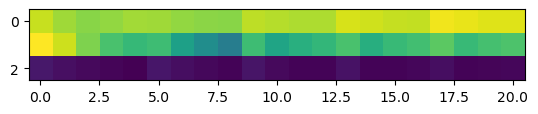

In [14]:
# sanity check: each row having roughly consistent color suggests we haven't mixed up our x, y, z dimensions 
# with all the averaging and reshaping
plt.imshow(x_mean[:, :, 0].T)

In [15]:
x_mean.shape

(21, 3, 35)

In [16]:
# build a template as average of all trials (across different conditions)
x_mean_template = x_mean.mean(axis=2)

In [17]:
x_mean_registered = np.empty_like(x_mean)
for trial_idx in range(x_mean.shape[2]):
    _x = x_mean[:, :, trial_idx]

    # adding bias col of 1s (offset)
    _x = np.hstack((np.ones((_x.shape[0], 1)), _x))

    # compute min MSE transformation back to template space
    a = np.linalg.pinv(_x[palm_idx, :]) @ x_mean_template[palm_idx, :]

    # apply and store
    x_mean_registered[:, :, trial_idx] = _x @ a

### Graph Hands

In [18]:
edge_pairs = np.array([[0, 1], [1, 2], [2, 3], [3, 4],
                       [0, 5], [5,6], [6, 7], [7, 8], 
                       [5, 9], [9, 10], [10, 11], [11, 12], 
                       [9, 13], [13, 14], [14, 15], [15, 16],
                       [13, 17], [17, 18], [18, 19], [19, 20],
                      [17, 0]])

def plot_hand(x_posisitons, y_positions, **kwargs):
    # Create a NetworkX graph
    G = nx.Graph()

    # Add nodes to the graph with (x, y) positions
    for i, (x, y) in enumerate(zip(x_posisitons, y_positions)):
        G.add_node(i, pos=(x, y))

    # Get positions of nodes
    node_positions = nx.get_node_attributes(G, 'pos')

    G.add_edges_from(edge_pairs)

    # Plot the graph
    nx.draw(G, pos=node_positions, with_labels=False, node_size=0, font_size=12, **kwargs)
    plt.plot()

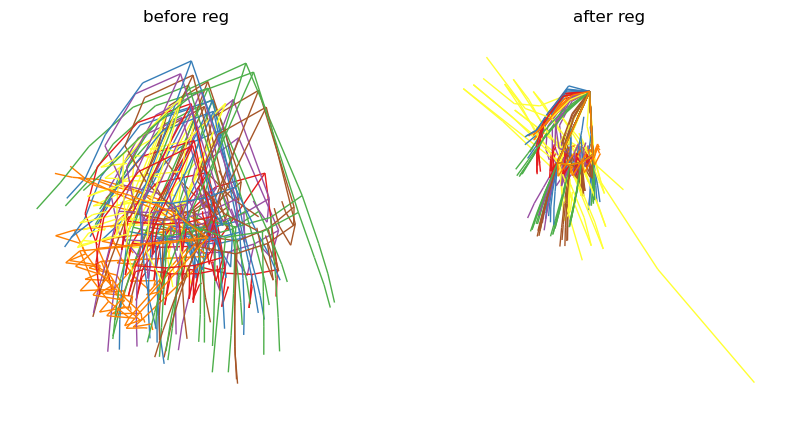

In [19]:
cmap = plt.get_cmap('Set1')

fig, ax = plt.subplots(1, 2)
fig.set_size_inches(10, 5)
for ax_idx, (label, x) in enumerate([('before reg', x_mean),
                                     ('after reg', x_mean_registered)]):
    plt.sca(ax[ax_idx])
    for trial_idx in range(x.shape[2]):
        _x = x[:, :, trial_idx]
        # networkx insists on a 2d array
        color = np.atleast_2d(cmap(y[trial_idx]))
        plot_hand(_x[:, 0], _x[:, 1], edge_color=color)
    ax[ax_idx].title.set_text(label)

### Classification

In [20]:
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from copy import copy
from sklearn.model_selection import KFold

In [21]:
x_mean_registered.shape

(21, 3, 35)

In [22]:
x_classify = x_mean_registered.reshape(21 * 3, y.size).T

# initialize a knn_classifier
knn_classifier = KNeighborsClassifier(n_neighbors=1)

# fit happens "inplace", we modify the internal state of knn_classifier to remember all the training samples
knn_classifier.fit(x_classify, y)

# estimate each penguin's species
y_pred = knn_classifier.predict(x_classify)

/Users/ericasammarco/opt/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:237: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


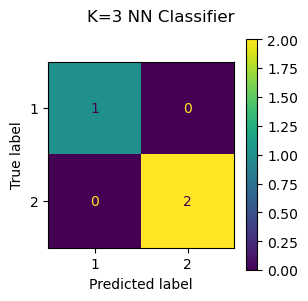

In [35]:
conf_mat = confusion_matrix(y_true=y, y_pred=y_pred)
conf_mat_disp = ConfusionMatrixDisplay(conf_mat, display_labels=np.unique(y))

conf_mat_disp.plot()
plt.suptitle('K=3 NN Classifier')
plt.gcf().set_size_inches(3, 3)
plt.grid(False)

In [36]:
y.size

3

In [34]:
# initialize a knn_classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# construction of kfold object
kfold = KFold(n_splits= y.size, shuffle=True)

# allocate an empty array to store predictions in
y_pred = copy(y)

for train_idx, test_idx in kfold.split(x_classify, y):
    # build arrays which correspond to x, y train /test
    x_test = x_classify[test_idx, :]
    x_train = x_classify[train_idx, :]
    y_true_train = y[train_idx]
    
    # fit happens "inplace", we modify the internal state of knn_classifier to remember all the training samples
    knn_classifier.fit(x_train, y_true_train)

    # estimate each penguin's species
    y_pred[test_idx] = knn_classifier.predict(x_test)

# build and plot confusion matrix
conf_mat = confusion_matrix(y_true=y, y_pred=y_pred)
conf_mat_disp = ConfusionMatrixDisplay(conf_mat, display_labels=np.unique(y))

conf_mat_disp.plot()
plt.suptitle('K=1 NN Cross-Validated Classifier')
plt.gcf().set_size_inches(3, 3)
plt.grid(False)

ValueError: Found input variables with inconsistent numbers of samples: [35, 3]

In [26]:
from sklearn import svm

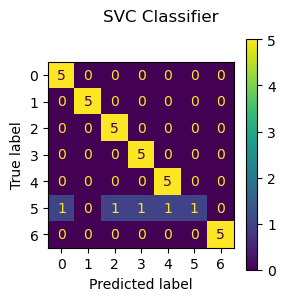

In [27]:
clf = svm.SVC()
clf.fit(x_classify, y)
y_pred = clf.predict(x_classify)

# build and plot confusion matrix
conf_mat = confusion_matrix(y_true=y, y_pred=y_pred)
conf_mat_disp = ConfusionMatrixDisplay(conf_mat, display_labels=np.unique(y))

conf_mat_disp.plot()
plt.suptitle('SVC Classifier')
plt.gcf().set_size_inches(3, 3)
plt.grid(False)

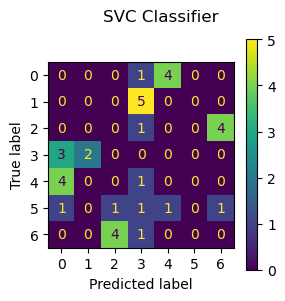

In [28]:
# SVC Cross-Validation

# initialize classifier
clf = svm.SVC()

# construction of kfold object
kfold = KFold(n_splits= int(y.size / 2))

# allocate an empty array to store predictions in
y_pred = copy(y)

for train_idx, test_idx in kfold.split(x_classify, y):
    # build arrays which correspond to x, y train /test
    x_test = x_classify[test_idx, :]
    x_train = x_classify[train_idx, :]
    y_true_train = y[train_idx]
    
    # fit happens "inplace", we modify the internal state of knn_classifier to remember all the training samples
    clf.fit(x_train, y_true_train)

    # estimate each penguin's species
    y_pred[test_idx] = clf.predict(x_test)

# build and plot confusion matrix
conf_mat = confusion_matrix(y_true=y, y_pred=y_pred)
conf_mat_disp = ConfusionMatrixDisplay(conf_mat, display_labels=np.unique(y))

conf_mat_disp.plot()
plt.suptitle('SVC Classifier')
plt.gcf().set_size_inches(3, 3)
plt.grid(False)

NameError: name 'StratifiedKFold' is not defined

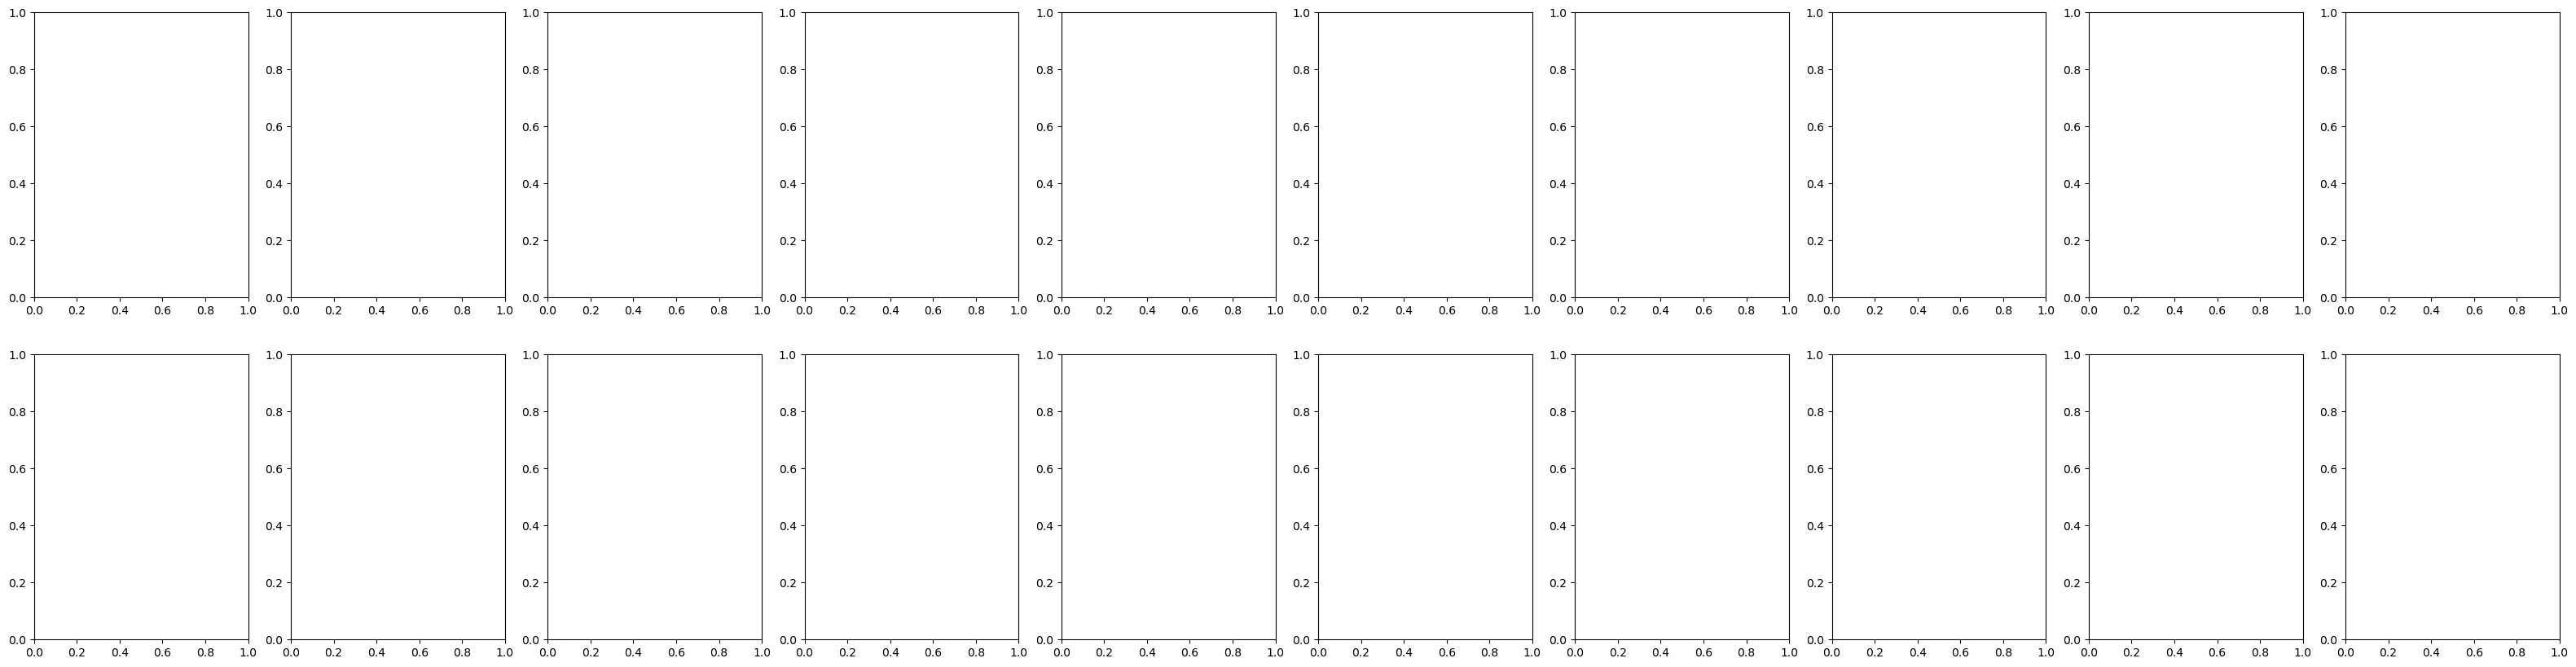

In [29]:
# Classifier Comparison

from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=42),
    SVC(gamma=2, C=1, random_state=42),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=1, random_state=42
    ),
    MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    AdaBoostClassifier(algorithm="SAMME", random_state=42),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]


fig, ax = plt.subplots(2, len(classifiers), figsize=(40, 10))
kfold = StratifiedKFold(n_splits=3)

# iterate over classifiers
i = 0
for name, clf in zip(names, classifiers):
    #clf = make_pipeline(StandardScaler(), clf)
    clf.fit(x_classify, y)
    y_pred = clf.predict(x_classify)
    
    conf_mat = confusion_matrix(y_true=y, y_pred=y_pred)
    conf_mat_disp = ConfusionMatrixDisplay(conf_mat, display_labels=np.unique(y))
    
    conf_mat_disp.plot(ax = ax[0, i], colorbar = False)
    ax[0, i].set_title(name)
    
    for train_idx, test_idx in kfold.split(x_classify, y):
        # build arrays which correspond to x, y train /test
        x_test = x_classify[test_idx, :]
        x_train = x_classify[train_idx, :]
        y_true_train = y[train_idx]
    
        # fit happens "inplace", we modify the internal state of knn_classifier to remember all the training samples
        clf.fit(x_train, y_true_train)

        # estimate each penguin's species
        y_pred[test_idx] = clf.predict(x_test)

    # build and plot confusion matrix
    conf_mat = confusion_matrix(y_true=y, y_pred=y_pred)
    conf_mat_disp = ConfusionMatrixDisplay(conf_mat, display_labels=np.unique(y))
    
    conf_mat_disp.plot(ax = ax[1, i], colorbar = False)
    ax[1, i].set_title(name + " Cross Validation")
    
    i += 1
    
plt.show()

In [ ]:
clf = GaussianNB()
clf.fit(x_classify, y)
y_pred = clf.predict(x_classify)

# build and plot confusion matrix
conf_mat = confusion_matrix(y_true=y, y_pred=y_pred)
conf_mat_disp = ConfusionMatrixDisplay(conf_mat, display_labels=np.unique(y))

conf_mat_disp.plot()
plt.suptitle('Linear')
plt.gcf().set_size_inches(3, 3)
plt.grid(False)

In [ ]:
# construction of kfold object
#kfold = KFold(n_splits= int(y.size / 2))
kfold = StratifiedKFold(n_splits=3)

# allocate an empty array to store predictions in
y_pred = copy(y)

for train_idx, test_idx in kfold.split(x_classify, y):
    # build arrays which correspond to x, y train /test
    x_test = x_classify[test_idx, :]
    x_train = x_classify[train_idx, :]
    y_true_train = y[train_idx]
    
    # fit happens "inplace", we modify the internal state of knn_classifier to remember all the training samples
    clf.fit(x_train, y_true_train)

    # estimate each penguin's species
    y_pred[test_idx] = clf.predict(x_test)

# build and plot confusion matrix
conf_mat = confusion_matrix(y_true=y, y_pred=y_pred)
conf_mat_disp = ConfusionMatrixDisplay(conf_mat, display_labels=np.unique(y))

conf_mat_disp.plot()
plt.suptitle('Linear SVM Cross-Validation')
plt.gcf().set_size_inches(3, 3)
plt.grid(False)